In [2]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats

from lib.plots import set_axis
from lib.stats import fit_power_law

In [51]:
task_ids = [
    "task-1-control",
    "task-2-delcohesin",
    "task-3-acetyl",
    "task-4-acetyl_delcohesin",
]

@dataclasses.dataclass
class Metrics:
    files: list[str]
    config: dict
    site_msds: np.ndarray
    domain_rgs: np.ndarray
    separation_scores: np.ndarray

conds_metrics = {}

for task_id in task_ids:
    with h5py.File(f"{task_id}/_outputs/metrics.h5", "r") as store:
        conds_metrics[task_id] = Metrics(
            files=[s.decode() for s in store["files"][()]],
            config=json.loads(store["config"][()]),
            site_msds=store["site_msds"][:, :, :],
            domain_rgs=store["domain_rgs"][:],
            separation_scores=store["separation_scores"][:],
        )

In [141]:
@dataclasses.dataclass
class Style:
    label: str
    color: object

conds_styles = {
    #"task-1-control":           Style(label="normal",       color="black"),
    #"task-2-delcohesin":        Style(label="Δcohesin",     color="red"),
    #"task-3-acetyl":            Style(label="Ac+",          color="black"),
    #"task-4-acetyl_delcohesin": Style(label="Δcohesin Ac+", color="red"),
    "task-1-control":           Style(label="normal",       color="black"),
    "task-2-delcohesin":        Style(label="Δcohesin",     color="red"),
    "task-3-acetyl":            Style(label="Ac+",          color="orange"),
    "task-4-acetyl_delcohesin": Style(label="Δcohesin Ac+", color="purple"),
}

In [142]:
@dataclasses.dataclass
class MSDAnalysis:
    lags: np.ndarray
    means: np.ndarray
    stds: np.ndarray
    alpha: float
    beta: float

In [143]:
reference_lag = 10

conds_msds = {}

for task_id, metrics in conds_metrics.items():
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    site_msds = metrics.site_msds[:, :reference_lag + 1, :]
    lags = np.arange(site_msds.shape[1]) * frame_interval
    msd_samples = einops.rearrange(site_msds, "r t s -> (r s) t")
    msd_mean = msd_samples.mean(axis=0)
    msd_std = msd_samples.std(axis=0)

    x = lags
    y = msd_mean
    alpha, beta = fit_power_law(x, y)

    conds_msds[task_id] = MSDAnalysis(
        lags=lags,
        means=msd_mean,
        stds=msd_std,
        alpha=alpha,
        beta=beta,
    )

In [144]:
for key, analysis in conds_msds.items():
    print("{:24s} α={:.3g} Deff={:.3g}".format(key, analysis.alpha, analysis.beta))

task-1-control           α=0.572 Deff=15.2
task-2-delcohesin        α=0.581 Deff=16.9
task-3-acetyl            α=0.553 Deff=28.6
task-4-acetyl_delcohesin α=0.589 Deff=35.6


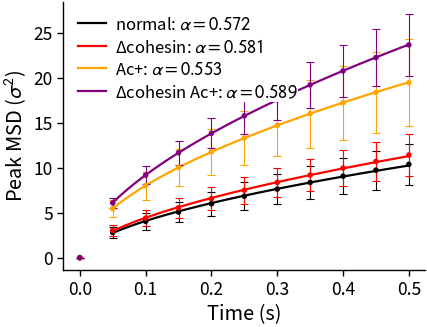

In [145]:
fig, ax = plt.subplots(figsize=(2.2, 1.7))

for task_id, msd in conds_msds.items():
    cond_style = conds_styles[task_id]
    label = cond_style.label
    color = cond_style.color

    x = msd.lags
    y = msd.means
    y_err = msd.stds
    ax.errorbar(x, y, y_err, color=color, linewidth=0, elinewidth=0.4, capsize=1.3, capthick=0.4, zorder=2)
    ax.scatter(x, y, s=4, ec="none", fc=color, zorder=3)

    x = np.linspace(msd.lags[1], msd.lags[-1], num=100)
    y = x**msd.alpha * msd.beta
    s = f"{label}: " r"$ \alpha = %.3f $" % msd.alpha
    ax.plot(x, y, lw=0.8, color=color, label=s)

ax.legend(frameon=True)
ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"Peak MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/msd.{ext}", transparent=True)

pass

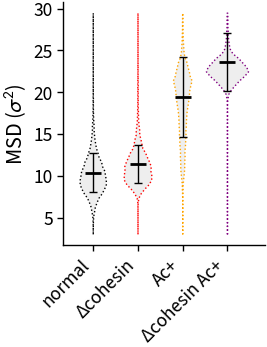

In [146]:
msd_bins = np.linspace(3, 30, num=51)
density_scale = 1.5

fig, ax = plt.subplots(figsize=(1.4, 1.8))

for i, (task_id, metrics) in enumerate(conds_metrics.items()):
    style = conds_styles[task_id]
    msds = metrics.site_msds[:, reference_lag, :].ravel()

    values = msds

    density, _ = np.histogram(
        values,
        bins=msd_bins,
        density=True,
    )
    ax.fill_betweenx(
        msd_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec=style.color,
        fc="#eee",
        ls=":",
        zorder=2,
    )

    mean = values.mean()
    std = values.std()
    x = [i]
    y = [mean]
    y_err = [std]
    ax.errorbar(x, y, y_err, color="k", marker="_", elinewidth=0.5, capsize=1.5, capthick=0.5)

ax.margins(x=0.1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(
    [conds_styles[key].label for key in conds_metrics.keys()],
    horizontalalignment="right",
    rotation=45,
)
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/max_msd.{ext}", transparent=True)

pass

In [147]:
import pandas as pd

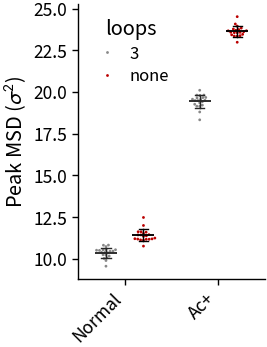

In [148]:
@dataclasses.dataclass
class SwarmData:
    label: str
    values: np.ndarray

swarm_data = [
    SwarmData(
        label=conds_styles[task_id].label,
        values=metrics.site_msds[:, reference_lag, :].mean(axis=-1),
    )
    for task_id, metrics in conds_metrics.items()
]

sample_conditions = {
    "task-1-control":           {"chromatin": "Normal", "loops": "3"},
    "task-2-delcohesin":        {"chromatin": "Normal", "loops": "none"},
    "task-3-acetyl":            {"chromatin": "Ac+", "loops": "3"},
    "task-4-acetyl_delcohesin": {"chromatin": "Ac+", "loops": "none"},
}

swarm_data = pd.concat([
    pd.DataFrame(
        {
            **conditions,
            "msd": conds_metrics[task_id].site_msds[:, reference_lag, :].mean(axis=-1),
        }
    )
    for task_id, conditions in sample_conditions.items()
])

fig, ax = plt.subplots(figsize=(1.4, 1.8))

sns.swarmplot(
    swarm_data,
    x="chromatin",
    y="msd",
    hue="loops",
    dodge=0.4,
    size=1,
    palette={"3": "#888", "none": "#b00"},
    zorder=1,
    ax=ax,
)

sns.pointplot(
    swarm_data,
    x="chromatin",
    y="msd",
    hue="loops",
    dodge=0.4,
    linestyle="none",
    errorbar="sd",
    capsize=0.1,
    err_kws=dict(linewidth=0.5),
    markers="_",
    markersize=8,
    palette="dark:black",
    legend=False,
    zorder=2,
    ax=ax,
)

#for label in ax.get_xticklabels():
#    label.set_horizontalalignment("right")
#    label.set_rotation(30)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Normal", "Ac+"], ha="right", rotation=45)

ax.set_xlabel("")
ax.set_ylabel(r"Peak MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/max_msd_swarm.{ext}", transparent=True)

pass

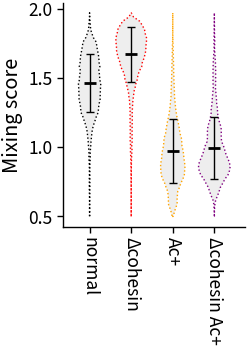

In [149]:
score_bins = np.linspace(0.5, 2.0, num=51)
density_scale = 0.15

fig, ax = plt.subplots(figsize=(1.3, 1.8))

for i, (task_id, metrics) in enumerate(conds_metrics.items()):
    color = conds_styles[task_id].color

    values = (1 / metrics.separation_scores).ravel()

    density, _ = np.histogram(
        values,
        bins=score_bins,
        density=True,
    )
    ax.fill_betweenx(
        score_bins[:-1],
        i + density * density_scale,
        i - density * density_scale,
        ec=color,
        fc="#eee",
        ls=":",
        zorder=2,
    )

    mean = values.mean()
    std = values.std()
    x = [i]
    y = [mean]
    y_err = [std]
    ax.errorbar(x, y, y_err, color="k", elinewidth=0.5, capsize=1.5, capthick=0.5)
    ax.plot(x, y, marker="_", color="k", markersize=4)

ax.margins(x=0.1)

ax.set_xticks(np.arange(len(conds_metrics)))
ax.set_xticklabels(
    [conds_styles[key].label for key in conds_metrics.keys()],
    rotation=-90,
)
ax.set_ylabel("Mixing score")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/mixing_score.{ext}", transparent=True)

pass

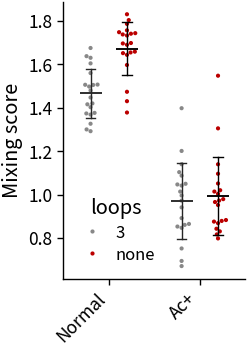

In [158]:
swarm_data = pd.concat([
    pd.DataFrame(
        {
            **conditions,
            "mixing_score": (1 / conds_metrics[task_id].separation_scores).mean(axis=-1),
        }
    )
    for task_id, conditions in sample_conditions.items()
])

fig, ax = plt.subplots(figsize=(1.3, 1.8))

sns.swarmplot(
    swarm_data,
    x="chromatin",
    y="mixing_score",
    hue="loops",
    dodge=0.4,
    size=1.5,
    palette={"3": "#888", "none": "#b00"},
    zorder=1,
    ax=ax,
)

sns.pointplot(
    swarm_data,
    x="chromatin",
    y="mixing_score",
    hue="loops",
    dodge=0.4,
    linestyle="none",
    errorbar="sd",
    capsize=0.1,
    err_kws=dict(linewidth=0.5),
    markers="_",
    markersize=8,
    palette="dark:black",
    legend=False,
    zorder=2,
    ax=ax,
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Normal", "Ac+"], ha="right", rotation=45)

ax.set_xlabel("")
ax.set_ylabel("Mixing score")

set_axis(ax, "left bottom")

for ext in ["svg", "png"]:
    fig.savefig(f"_figs/mixing_score_swarm.{ext}", transparent=True)

pass

In [151]:
mixing_scores = {
    task_id: (1 / metrics.separation_scores).ravel() #.mean(-1)
    for task_id, metrics in conds_metrics.items()
}


test = scipy.stats.ttest_rel(
    mixing_scores["task-1-control"],
    mixing_scores["task-2-delcohesin"],
)
print(test)

TtestResult(statistic=-93.73293928852713, pvalue=0.0, df=20019)
